# L'estimateur de référence saine — NIST 14 & 16 SEER

Le système a deux étages. L'étage 2 (classifieur) a été comparé en X2. **L'étage 1 — ce que lirait la machine si elle allait bien — n'avait été qu'effleuré.**

```
conditions + mesures
      ↓
[ étage 1 — estimateur de référence saine ]
      ↓  résidus = mesuré − sain
[ étage 2 — classifieur ]     GradientBoostingClassifier(random_state=42)
```

Le 0,602 publié est un kNN, k=5, **médiane**, sur `(T_source, T_sink)`, essais sains de la machine cible. Personne n'avait vérifié si c'était le bon choix, ni **ce que ce choix suppose**.

**Le livrable n'est pas « quel estimateur gagne ».** C'est la courbe `dmin → accuracy` : combien la performance dépend de la proximité d'un essai sain.

### Protocole

Leave-one-machine-out, les deux sens. Le classifieur est **figé** : résidus d'entraînement = kNN k=5 médiane sur les sains du train. Seule la référence du **test** change. C'est le protocole du 0,602.

Pression d'aspiration : `1701_ODVapSV_psia`, jamais `1710`. `EF` / `CF` / `LL` / `UC/OC` / `NF` ne sont pas des features.

`dmin` est euclidien en `(T_source, T_sink)` — la même métrique que le kNN.

> Données non versionnées : `data/nist/fdd_1416seer.xlsx`.
> Grille complète : `EDA/x3_compute.py` (~2 min). Ce notebook recharge la table et refait le contrôle.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'EDA'))
from x3_compute import (
    load, knn_estimate, COND2, COND3, RES, LABELS, DMINS, FIG, TABLE,
)
from sklearn.ensemble import GradientBoostingClassifier
from scipy.spatial import cKDTree
from tools.results import value, get

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': GRID,
    'axes.labelcolor': MUTED, 'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})

X, y, grp = load()
print(f'{len(X)} lignes · {y.nunique()} classes')
print(dict(y.value_counts()))
print('sains par machine :', dict(y[y == 'No_Fault'].groupby(grp).size()))


5386 lignes · 6 classes
{'No_Fault': np.int64(1352), 'Undercharge': np.int64(1228), 'Overcharge': np.int64(942), 'Evap_Airflow': np.int64(774), 'LiquidLine': np.int64(593), 'Cond_Blockage': np.int64(497)}
sains par machine : {14.0: np.int64(727), 16.0: np.int64(625)}


## 1 — Le plan d'essais est répliqué

In [2]:
d_euc = []
for seer in (14.0, 16.0):
    h = X.loc[(grp == seer) & (y == 'No_Fault'), COND2].to_numpy()
    f = X.loc[(grp == seer) & (y != 'No_Fault'), COND2].to_numpy()
    d, _ = cKDTree(h).query(f, k=1)
    d_euc.append(d)
    print(f'SEER {int(seer)}  défaillants={len(f)}  d<0,1 °C={(d < 0.1).mean():.1%}  d<0,5 °C={(d < 0.5).mean():.1%}')
d_euc = np.concatenate(d_euc)
print(f'ensemble  n={len(d_euc)}  d<0,1 °C={(d_euc < 0.1).mean():.1%}  d<0,5 °C={(d_euc < 0.5).mean():.1%}')
print('un petit k mesure le plan d\'expérience, pas la physique')


SEER 14  défaillants=1693  d<0,1 °C=25.9%  d<0,5 °C=75.8%
SEER 16  défaillants=2341  d<0,1 °C=29.4%  d<0,5 °C=68.3%
ensemble  n=4034  d<0,1 °C=27.9%  d<0,5 °C=71.5%
un petit k mesure le plan d'expérience, pas la physique


## 2 — Contrôle : reproduire 0,602

`cKDTree` + `np.median` sur k=5. `KNeighborsRegressor` de sklearn utilise la **moyenne**.

In [3]:
folds = {}
for test_seer in (14.0, 16.0):
    tr, te = grp != test_seer, grp == test_seer
    h_tr, h_te = tr & (y == 'No_Fault'), te & (y == 'No_Fault')
    pred_tr = knn_estimate(X.loc[h_tr, COND2], X.loc[h_tr, RES], X.loc[tr, COND2], k=5, agg='median')
    clf = GradientBoostingClassifier(random_state=42).fit(X.loc[tr, RES].to_numpy() - pred_tr, y.loc[tr])
    folds[test_seer] = dict(te=te, h_te=h_te, clf=clf)

accs, f1s = [], []
for test_seer, f in folds.items():
    pred = knn_estimate(X.loc[f['h_te'], COND2], X.loc[f['h_te'], RES], X.loc[f['te'], COND2], k=5, agg='median')
    hat = f['clf'].predict(X.loc[f['te'], RES].to_numpy() - pred)
    accs.append(accuracy_score(y.loc[f['te']], hat))
    f1s.append(f1_score(y.loc[f['te']], hat, average='macro'))
print(f'knn5 médiane (T,T)  acc={np.mean(accs):.3f}  F1={np.mean(f1s):.3f}  plis={accs[0]:.3f}/{accs[1]:.3f}')
assert abs(np.mean(accs) - 0.602) < 0.008, np.mean(accs)
print('contrôle OK')
print('sklearn mean k=5 (piège) :', round(value(experiment='X3', protocol='LOMO',
    reference='sklearn-KNeighborsRegressor-mean-k5-TT-dmin0', metric='accuracy'), 3))


knn5 médiane (T,T)  acc=0.602  F1=0.479  plis=0.637/0.568
contrôle OK
sklearn mean k=5 (piège) : 0.554


La médiane du projet vaut **4,8 points** sur la moyenne sklearn à k=5 (0,602 contre 0,554). Ce n'est pas un détail d'implémentation.

## 3 — La courbe `dmin → accuracy`

Toute la grille (kNN × agrégation × pondération × rosée × dmin, planchers, lin / poly2 / ridge, RF) est dans `outputs/x3_estimator_dmin.csv`, journalisée sous `experiment=X3`. Pour la recalculer : `python EDA/x3_compute.py`.

kNN k=5 médiane (T,T) — publié
 dmin   acc    f1
 0.00 0.602 0.479
 0.10 0.519 0.431
 0.25 0.499 0.408
 0.50 0.482 0.400
 1.00 0.452 0.374
 2.00 0.434 0.354
figure → docs/nist_x3_dmin.png


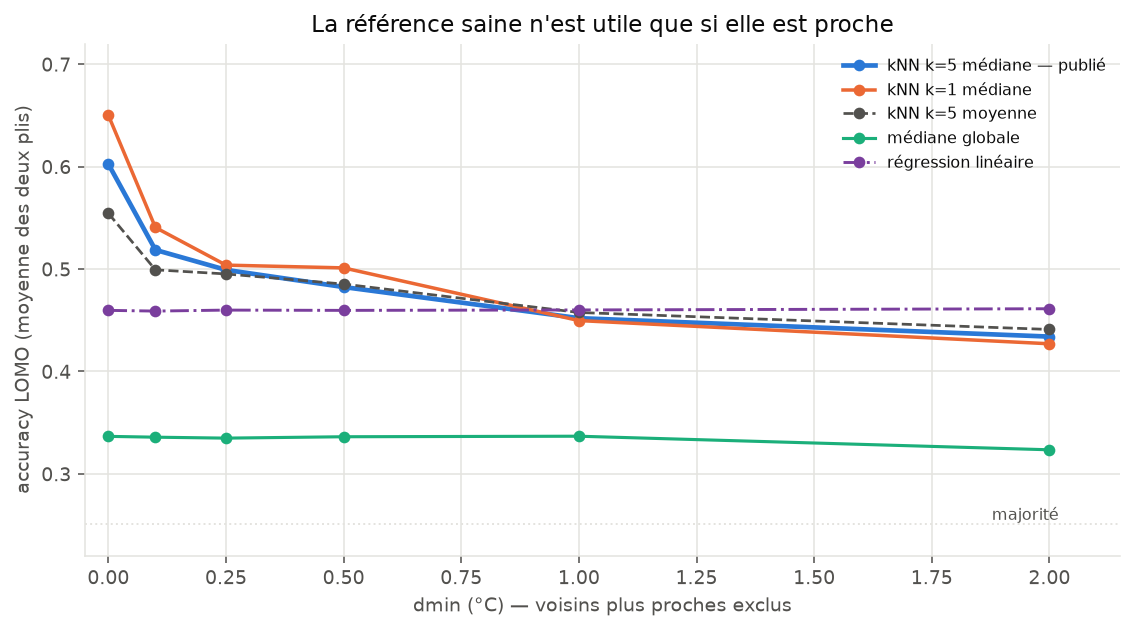

In [4]:
tab = pd.read_csv(TABLE)
knn5 = tab[(tab.estimator == 'knn-k5-median-unif') & (tab.dew == 'TT')].sort_values('dmin')
print('kNN k=5 médiane (T,T) — publié')
print(knn5[['dmin', 'acc', 'f1']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=140)
series = [
    ('knn-k5-median-unif', 'TT', 'kNN k=5 médiane — publié', BLUE, 2.4, '-'),
    ('knn-k1-median-unif', 'TT', 'kNN k=1 médiane', ORANGE, 1.8, '-'),
    ('knn-k5-mean-unif', 'TT', 'kNN k=5 moyenne', MUTED, 1.4, '--'),
    ('global-median', 'TT', 'médiane globale', AQUA, 1.6, '-'),
    ('lin', 'TT', 'régression linéaire', '#7a3e9d', 1.5, '-.'),
]
for est, dew, lab, color, lw, ls in series:
    sub = tab[(tab.estimator == est) & (tab.dew == dew)].sort_values('dmin')
    ax.plot(sub.dmin, sub.acc, ls, color=color, lw=lw, marker='o', ms=5, label=lab)
ax.axhline(0.251, color=GRID, lw=1, ls=':')
ax.text(2.02, 0.255, 'majorité', ha='right', color=MUTED, fontsize=8)
ax.set_xlabel('dmin (°C) — voisins plus proches exclus')
ax.set_ylabel('accuracy LOMO (moyenne des deux plis)')
ax.set_title('La référence saine n\'est utile que si elle est proche')
ax.legend(frameon=False, loc='upper right', fontsize=8)
ax.set_xlim(-0.05, 2.15)
ax.set_ylim(0.22, 0.72)
fig.tight_layout()
fig.savefig(FIG, bbox_inches='tight', dpi=140)
print('figure →', FIG.relative_to(ROOT))


À 0,5 °C — une machine en service n'a pas de jumeau sain à 0,1 °C — le kNN k=5 publié tombe à **0,482**. Le k=1 qui « gagnait » à dmin=0 (0,650) retombe au même étage (0,501). Le gain du petit k **était le plan d'essais**.

Les surfaces (linéaire, polynôme, ridge) sont plates sur `dmin` : ~0,46. Elles n'utilisent pas les répliques. Elles ne rattrapent pas le kNN dès que les répliques sont interdites, et elles sont loin du 0,602.

## 4 — L'erreur d'estimation ne prédit pas la classification

Le point de rosée (`1703_VDC_KahnDewTempF`) dans le kNN **des deux étages** (train et test) :

In [5]:
print('knn5 médiane, rosée train+test : acc',
      round(value(experiment='X3', protocol='LOMO',
                  reference='knn5-median-TTdew-train+test-dmin0', metric='accuracy'), 3))
print('sans rosée (publié)             : acc 0.602')
print('rosée au test seulement         : acc',
      round(float(tab[(tab.estimator=='knn-k5-median-unif') & (tab.dew=='TTdew') & (tab.dmin==0)].acc.iloc[0]), 3))


knn5 médiane, rosée train+test : acc 0.576
sans rosée (publié)             : acc 0.602
rosée au test seulement         : acc 0.6


0,602 → **0,576**. La MAE leave-one-out sur les sains s'améliore légèrement. Juger l'étage 1 sur l'erreur de régression aurait **choisi la variante qui perd en bout de chaîne**.

Pondération inverse-distance à dmin=0 : accuracy ~0,65 et MAE saine = 0. L'essai sain *lui-même* (les `No_Fault` du test sont dans le pool) avale tout le poids. Ce n'est pas un estimateur, c'est une fuite. Dès que `dmin>0`, le « gain » disparaît.

## 5 — Par panne, kNN k=5

In [6]:
def show(ref):
    rows = get(experiment='X3', protocol='LOMO', reference=ref, metric='f1')
    rows = [r for r in rows if r['label'] != '__global__']
    print(ref)
    for r in rows:
        print(f"  {r['label']:16s}  F1={float(r['value']):.3f}  n={r['n']}")

show('knn-k5-median-unif-TT-dmin0')
show('knn-k5-median-unif-TT-dmin0.5')


knn-k5-median-unif-TT-dmin0
  Cond_Blockage     F1=0.287  n=497
  Evap_Airflow      F1=0.303  n=774
  LiquidLine        F1=0.040  n=593
  No_Fault          F1=0.735  n=1352
  Overcharge        F1=0.695  n=942
  Undercharge       F1=0.854  n=1228
knn-k5-median-unif-TT-dmin0.5
  Cond_Blockage     F1=0.293  n=497
  Evap_Airflow      F1=0.245  n=774
  LiquidLine        F1=0.042  n=593
  No_Fault          F1=0.434  n=1352
  Overcharge        F1=0.661  n=942
  Undercharge       F1=0.841  n=1228


**Sans défaut : F1 0,735 → 0,434.** Les défauts de charge tiennent. Le 0,120 d'accuracy perdu à dmin=0,5, c'est surtout cesser de reconnaître un jumeau sain.

## 6 — Verdict

| | acc LOMO |
|---|---|
| kNN k=5 médiane, répliques autorisées — **protocole publié** | **0,602** |
| le même, voisins à moins de 0,5 °C interdits | **0,482** |
| kNN k=1, répliques autorisées | 0,650 |
| kNN k=1, dmin=0,5 °C | 0,501 |
| médiane globale (pas de condition) | 0,337 |
| moyenne globale | 0,328 |
| polynôme / ridge / linéaire | ~0,46 |
| kNN k=5 + rosée, train et test | 0,576 |

Le 0,602 **tient comme score du protocole de chambre** (un sain existe aux mêmes conditions). Il **ne tient pas** comme performance de référence d'une machine en service. L'exploration préliminaire disait 0,511 ; la mesure propre donne **0,482**.

Les cinq documents qui citent 0,602 comme chiffre du projet sont listés dans `docs/NIST_FINDINGS.md`. **Pas corrigés ici** — PR séparée.
